# Introducción

# Exploratory Data Analysis

Empezaremos por analizar la data proporcionada para poder sacar información relevante para el pre-procesado y modelaje.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN, KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score

from DBCV import DBCV

def nl():
    print('\n')


# Helper function to format tables
def show_df(dataframe, precision=2, width="100%", percent_cols=None):
    styler = (
        dataframe.style
        .format(precision=precision, na_rep="NaN")
        .set_table_attributes(f'style="width:{width}"')
        .set_table_styles([
            {"selector": "th", "props": [("text-align", "left"), ("padding", "6px 10px")]},
            {"selector": "td", "props": [("text-align", "left"), ("padding", "6px 10px")]},
        ])
        .hide(axis="index")
    )

    if percent_cols:
        styler = styler.format({c: "{:.2f}%" for c in percent_cols})

    display(styler)


print("Datasets:")
!ls ../data

Tenemos el fichero `stars_data.csv` empecemos por analizarlo

## Carga de Data y Visión Géneral

El objetivo ahora es entender la estructura géneral de los datos y tener una idea inicial de la forma de nuestros datasets.

In [ ]:
df = pd.read_csv('../data/stars_data.csv')

print('Tamaño del dataset: ', str(df.shape))
print('Columnas: ', str(df.columns.values.tolist()))

Hay 6 features y 240 filas para usar en nuestro entrenamiento.

## Esquema de Variables

In [ ]:
summary = pd.DataFrame({
    "Feature": df.columns,
    "dtype": df.dtypes,
    "Unique Values": df.nunique(dropna=True).tolist(),

})
show_df(summary)

n = len(df)
constant_cols = df.columns[df.nunique() <= 1].tolist()
id_cols = df.columns[df.nunique() == n].tolist()

print("Constant columns:", constant_cols if constant_cols else "None")
print("Potential ID columns:", id_cols if id_cols else "None")

Podemos observar que tenemos 1 clase con números enteros, 3 con números single-precision y 2 categóricas de tipo string.

Procederé a analizarlas a mayor detalle, buscando entender como se distribuyen y en cuáles vale la pena indagar más a profundidad después.

### Variables Categóricas

Nos interesa saber su cardinalidad, si hay desbalances en las distribuciones, cúal es la categória dominante y si les faltan valores.

In [ ]:
cat = df.select_dtypes(include="str")

rows = []

for col in cat.columns:
    freq = (cat[col].value_counts(dropna=False, normalize=True) * 100).round(2)
    categories = ["NaN" if pd.isna(x) else x for x in freq.index]
    dist = [f"({catg}, {pct}%)" for catg, pct in zip(categories, freq.tolist())]

    rows.append(", ".join(dist))

summary = pd.DataFrame({
    "Feature": cat.columns,
    "n_categories": cat.nunique(dropna=True).tolist(),
    "missing_values": cat.isnull().sum().tolist(),
    "missing_values %": (cat.isnull().mean() * 100).round(2).values,
    "category_distribution_top": rows,
})

summary = summary.sort_values("n_categories", ascending=False)

show_df(summary)

Observaciones:
* No hay valores faltantes o clases extrañas como "unknown"
* En `Color`, la clase mayoritaria es Red (46.67%), luego Blue (23.33). Notamos un desbalance alto, con clases como Blue-White, Orange-Red, Yellowish, White-Yellow y Pale yellow orange con 0.42% de presencia.
* `Spectral_Class` también tiene un desbalance marcado, con M como clase mayoritaria (46.25%) y G como clase minoritaria (0.42%).

`Color` presenta inconsistencias en los valores categóricos, variantes de capitalización y formato representan la misma categoría física (ej. "Blue White", "Blue white", "Blue-white", "Blue-White"). Limpiemos estas categorías antes de continuar.


In [ ]:
df['Color'] = df['Color'].str.strip().str.lower().str.replace('-', ' ')
df['Color'] = df['Color'].replace({
    'yellowish white': 'yellow white',
    'white yellow': 'yellow white',
    'yellowish': 'yellow white',
    'whitish': 'white',
    'pale yellow orange': 'orange',
    'orange red': 'orange',
})
color_clean = df['Color'].value_counts().reset_index()
color_clean.columns = ['Color', 'Count']
color_clean['%'] = (color_clean['Count'] / color_clean['Count'].sum() * 100).round(2)
show_df(color_clean)

cat = df.select_dtypes(include="str")

Unifique categorías con poca presencia como "pale yellow orange" en categorías superiores ("orange" en este caso). No tiene sentido mantener clases con tan pocos valores, solo ensucia el EDA y añade ruido, así que busco la clase mayoritaria común y las incluyo manualmente.

# Variables Numéricas

In [ ]:
num = df.select_dtypes(include="number" )

def outlier_info_iqr(series):
    s = series.dropna()
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    m = (s < lower) | (s > upper)

    return {
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "Lower bound": lower,
        "Upper bound": upper,
        "Outliers": m.sum(),
        "Outliers (%)": m.mean() * 100
    }


summary = pd.DataFrame({
    "Feature": num.columns,
    "0_count": [(num[col] == 0).sum() for col in num.columns],
    "Min": [num[col].min() for col in num.columns],
    "Max": [num[col].max() for col in num.columns],
    "Range": [num[col].max() - num[col].min() for col in num.columns],
    "STD": [num[col].std() for col in num.columns],
    "Skewness": [num[col].skew() for col in num.columns],
    "Kurtosis": [num[col].kurtosis() for col in num.columns],
    "Mean": [num[col].mean() for col in num.columns],
    "Median": [num[col].median() for col in num.columns],
})

show_df(summary)

outlier_table = pd.DataFrame([
    {"Feature": col, **outlier_info_iqr(num[col])}
    for col in num.columns
])

show_df(outlier_table.sort_values("Outliers (%)", ascending=False))

fig, axes = plt.subplots(len(num.columns), 2, figsize=(12, 4 * len(num.columns)))

for i, col in enumerate(num.columns):
    # Distribución
    axes[i, 0].hist(num[col], bins=30)
    axes[i, 0].set_title(f'{col} - Distribution')

    # Boxplot para outliers
    axes[i, 1].boxplot(num[col])
    axes[i, 1].set_title(f'{col} - Boxplot')

plt.tight_layout()
plt.show()


Observaciones:
* Hay gran diferencia entre las escalas. `L` tiene un rango y desviación mayor que el resto, luego viene `Temperature`. `A_M` es mucho más reducido, teniendo un rango ~26000 veces más pequeño que `L`.
* `L` y `R` tienen asimetría positiva y kurtosis elevada. Esta concentración que se forma alrededor de 0 muestra que nuestra data es probablemente multimodal, con poblaciones distintas mezcladas. Podemos comenzar a notar clusters naturales. Esto también ocurre con `Temperature`.
    * Los outliers detectados por IQR pueden corresponder a poblaciones poco frecuentes, no a errores o ruido en los datos.
* `A_M` claramente tiene una distribución bimodal, con dos picos separados en ~-7 y ~12. Podemos observar una separación entre estrellas brillantes y tenues.

Con estas observaciones en mente, pasemos a analizar la relación inter-variable.

## Análisis Inter-Variable

Nos interesa entender la correlación entre las variables.

### Correlación entre Numéricas


In [ ]:
corr = num.corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

Hay que tomar en cuenta que la magnitud absoluta es una escala invertida, mientras más alta, más tenue la estrella.

Observaciones:
* La mayor correlación es entre `L` y `A_M` (-0.69). Esto tiene sentido, una estrella luminosa a 10 parsec es brillante. Igual con `A_M` y `Temperature` (-0.42), y `A_M` y `R` (-0.61). En general mientras mayor son los otros valores, menor `A_M`, por lo que la estrella es más brillante.
* `L` y `R` están correlacionadas (0.53), como es de esperarse, mientras más grande la estrella, más luminosa.
* `L` y `Temperature` tienen una correlación baja (0.39). Usualmente, esperaríamos que estrellas calientes ejerzan mayor luminosidad. Esto lo analizaremos más a detalle.
* El tamaño de la estrella `R` no se relaciona con su temperatura `Temperature`, la relación es casi 0. Significa que en este dataset coexisten estrellas frías enormes y estrellas calientes pequeñas, eso es exactamente la diferencia entre una supergigante roja y una enana blanca.
    * Además, como `R` está tan correlacionado con `L`, la correlación entre `Temperature` y `L` es menor, ya que `L` no está dada por un solo factor.

### Temperature vs. L

In [ ]:
def show_hr_graph(log_transform=False):
    plt.figure(figsize=(8, 6))
    plt.scatter(df['Temperature'], df['L'], alpha=0.6)
    plt.xlabel('Temperature (K)')
    plt.ylabel('L (Solar Luminosity)')
    plt.title('Hertzsprung-Russell Diagram (Log Transformed)' if log_transform else 'Hertzsprung-Russell Diagram')
    plt.gca().invert_xaxis()  # Astronomic convention, temp. decreases to the right
    if log_transform:
        plt.yscale('log')
        plt.xscale('log')
    plt.show()

show_hr_graph()

Podemos observar como estrellas con la misma temperatura pueden tener una diferencia tan grande de luminosidad. Esto es porque `L` no solo está dado por `Temperature`, también puede ser `R` u otro factor que la afecta.

Ahora bien, hay un problema más serio. Todos nuestros datos están acoplados alrededor del 0 en `L`, esto no es bueno, ya que PCA verá solo las gigantes y supergigantes, el resto va a ser indistinguible, probemos verlo con log transform.

In [ ]:
show_hr_graph(log_transform=True)

Ahora podemos observar una estructura más descriptiva. Podemos comenzar a notar clusters.

* La banda superior son las estrellas gigantescas, donde `R` es tan grande que la temperatura no influye. Por eso se forma una franja horizontal, la temperatura varia, pero la luminosidad sigue siendo gigantesca.
* Luego podemos observar una diagonal descendente, estas son estrellas que si dependen de temperatura, mientras mayor es, mayor su luminosidad.
* La nube de abajo a la derecha son estrellas frías y pequeñas, con poca luminosidad.
* El grupo disperso de abajo a la izquierda, son estrellas calientes, pero pequeñas, con poca luminosidad por su tamaño.

Estos 4 grupos se corresponden con los tipos conocidos: hipergigantes/supergigantes, secuencia principal, enanas rojas/marrones y enanas blancas.

### Categóricas vs. Numéricas

In [ ]:
fig, axes = plt.subplots(4, 2, figsize=(16, 24))

for i, col in enumerate(num.columns):
    spectral_order = ['O', 'B', 'A', 'F', 'G', 'K', 'M']
    sns.boxplot(data=df, x='Spectral_Class', y=col,
            order=spectral_order, ax=axes[i, 0])
    sns.boxplot(data=df, x='Color', y=col, ax=axes[i, 1])

    if col in ['L', 'R']:
        axes[i, 0].set_yscale('log')
        axes[i, 1].set_yscale('log')

    axes[i, 1].tick_params(axis='x', rotation=45)
    axes[i, 0].set_title(f'{col} by Spectral Class')
    axes[i, 1].set_title(f'{col} by Color')

plt.tight_layout()
plt.show()

Observaciones:
* Podemos observar que la media de `Spectral_Class` con `Temperature` va descendiendo. Esto es lo que esperamos, ya que `Spectral_Class` está correlacionada con temperatura, asi que mientras más progresamos por las clases espectrales, menor es a temperatura.
* `L` en base a `Spectral_Class` nos muestra como el grupo O, representando ~16% del dataset, son estrellas de alta luminosidad en mayoría.
    * La relación no es lineal, M, siendo la clase más fría y más representativa (~40%), nos muestra una varianza gigantesca de `L`. Esto tiene sentido, agrupamos estrellas frías y gigantes en la misma categoría que frías y enanas, por lo que la luminosidad varía mucho. Necesitamos `R` y `A_M` en conjunto con `Spectral_Class` para entender la imagen completa.
* En `A_M` y `Spectral_Class` observamos un caso similar que con `L`. El tamaño de la estrella no afecta su brillo cuando es muy caliente, por eso O tiene tan poca varianza y está en un rango donde `A_M` es menor (mayor brillo), igual que con `L`. Estrellas muy calientes son muy brillantes. Ocurre lo mismo con M que en el caso de `L`, no nos da la imagen completa.
* Las estrellas con mayor temperatura son las azules y azules-blancas, estás además representan gran parte de la muestra (~23%, ~17%).
    *  También podemos observar un gradiénte, de temperatura con color: rojo, naranja, amarillo, blanco y azul.
* El color rojo presenta alta varianza en L y R, similar a la clase espectral M, agrupa tanto enanas como supergigantes frías. Las estrellas azules y azul-blancas muestran alta luminosidad consistente con su alta temperatura.

## Conclusiones del EDA

El dataset contiene 240 estrellas con 6 features, 4 numéricas y 2 categóricas, sin valores faltantes.

El análisis muestra que los datos no son homogéneos: existen poblaciones distintas mezcladas en una misma distribución. Esto es visible en las distribuciones multimodales de `Temperature`, `L` y `R`, en la distribución bimodal de `A_M`, y de forma más clara en el diagrama de Hertzsprung-Russell, donde se distinguen 4 grupos naturales correspondientes a hipergigantes/supergigantes, secuencia principal, enanas rojas/marrones y enanas blancas. Esto valida que el problema de clustering tiene estructura en los datos.

`L` y `R` varían en varios órdenes de magnitud, lo que hace que en escala lineal las poblaciones menos representadas queden colapsadas. El diagrama HR confirmó que la escala logarítmica es necesaria para que estas poblaciones sean distinguibles.

Las variables categóricas muestran un gradiente claro: `Spectral_Class` sigue el orden de temperatura $O \to M$, y `Color` sigue un gradiente energético de azul a rojo. Ambos encoding ordinales están justificados. `Color` presentaba inconsistencias de capitalización y formato que fueron corregidas antes del análisis.

Los outliers detectados por IQR no son ruido, son poblaciones poco frecuentes como hipergigantes. No deben eliminarse.

## Implicaciones para El Pre-Procesado

* Había que eliminar clases sucias en `Color`, ya lo hicimos.
* Tenemos que hacer log transform de `L` y `R`.
* Hay que aplicar encoding ordinal en `Spectral_Class` y `Color`, ya que si tienen un orden lógico.
* Usamos `StandardScaler` por el rango gigante de las escalas.
* Hacemos PCA a 2 componentes.

# Pre-Procesado

In [ ]:

# Initial config.
NIA_SEED = 100502359
np.random.seed(NIA_SEED)
df_model = df.copy() # Copy so that modifications don't affect EDA.

# Log Transform
df_model['L'] = np.log10(df_model['L'])
df_model['R'] = np.log10(df_model['R'])

spectral_order = ['M', 'K', 'G', 'F', 'A', 'B', 'O']
color_order = ['red', 'orange', 'yellow white', 'white', 'blue white', 'blue']

num_vars    = df_model.select_dtypes(include="number").columns.tolist()
cat_vars    = df_model.select_dtypes(include="str").columns.tolist()

# Machine for Numbers (Scale)
num_pipeline = Pipeline([
    ('scale', StandardScaler())
])
# Machine for Words (Encode -> Scale)
cat_pipeline = Pipeline([
    ('encode', OrdinalEncoder(categories=[color_order, spectral_order])),
    ('scale', StandardScaler())
])

# Full pipeline
preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_vars),
    ('cat', cat_pipeline, cat_vars),
])

full_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('pca', PCA(n_components=2)) # SVD is deterministic, we don't need the random_seed
])

X_pca = full_pipeline.fit_transform(df_model)
print(X_pca.shape)

pca = full_pipeline.named_steps['pca']
print(f"Varianza explicada: {pca.explained_variance_ratio_}")
print(f"Varianza total: {pca.explained_variance_ratio_.sum():.2%}")
feature_names = num_vars + cat_vars
loadings = pd.DataFrame(
    pca.components_.T,
    columns=['PC1', 'PC2']
)
loadings.insert(0, 'Features', feature_names)
show_df(loadings)
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.6)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA - 2 Components')
plt.show()

El pre-procesado fue un éxito, con 94.68% de varianza, mantuvimos casi toda la información al acoplar. PC1 explica el 63.37% sola, usando todos los features, y PC2 31.13%, probablemente usando `L`, `R` y `A_M`. Hay que recordar que `A_M` es una escala invertida.

El scatter plot PCA revela 4 grupos visualmente distinguibles, lo que sugiere que K=4 a K=6 son candidatos razonables para los algoritmos de clustering.

# Algoritmos

## K-Means

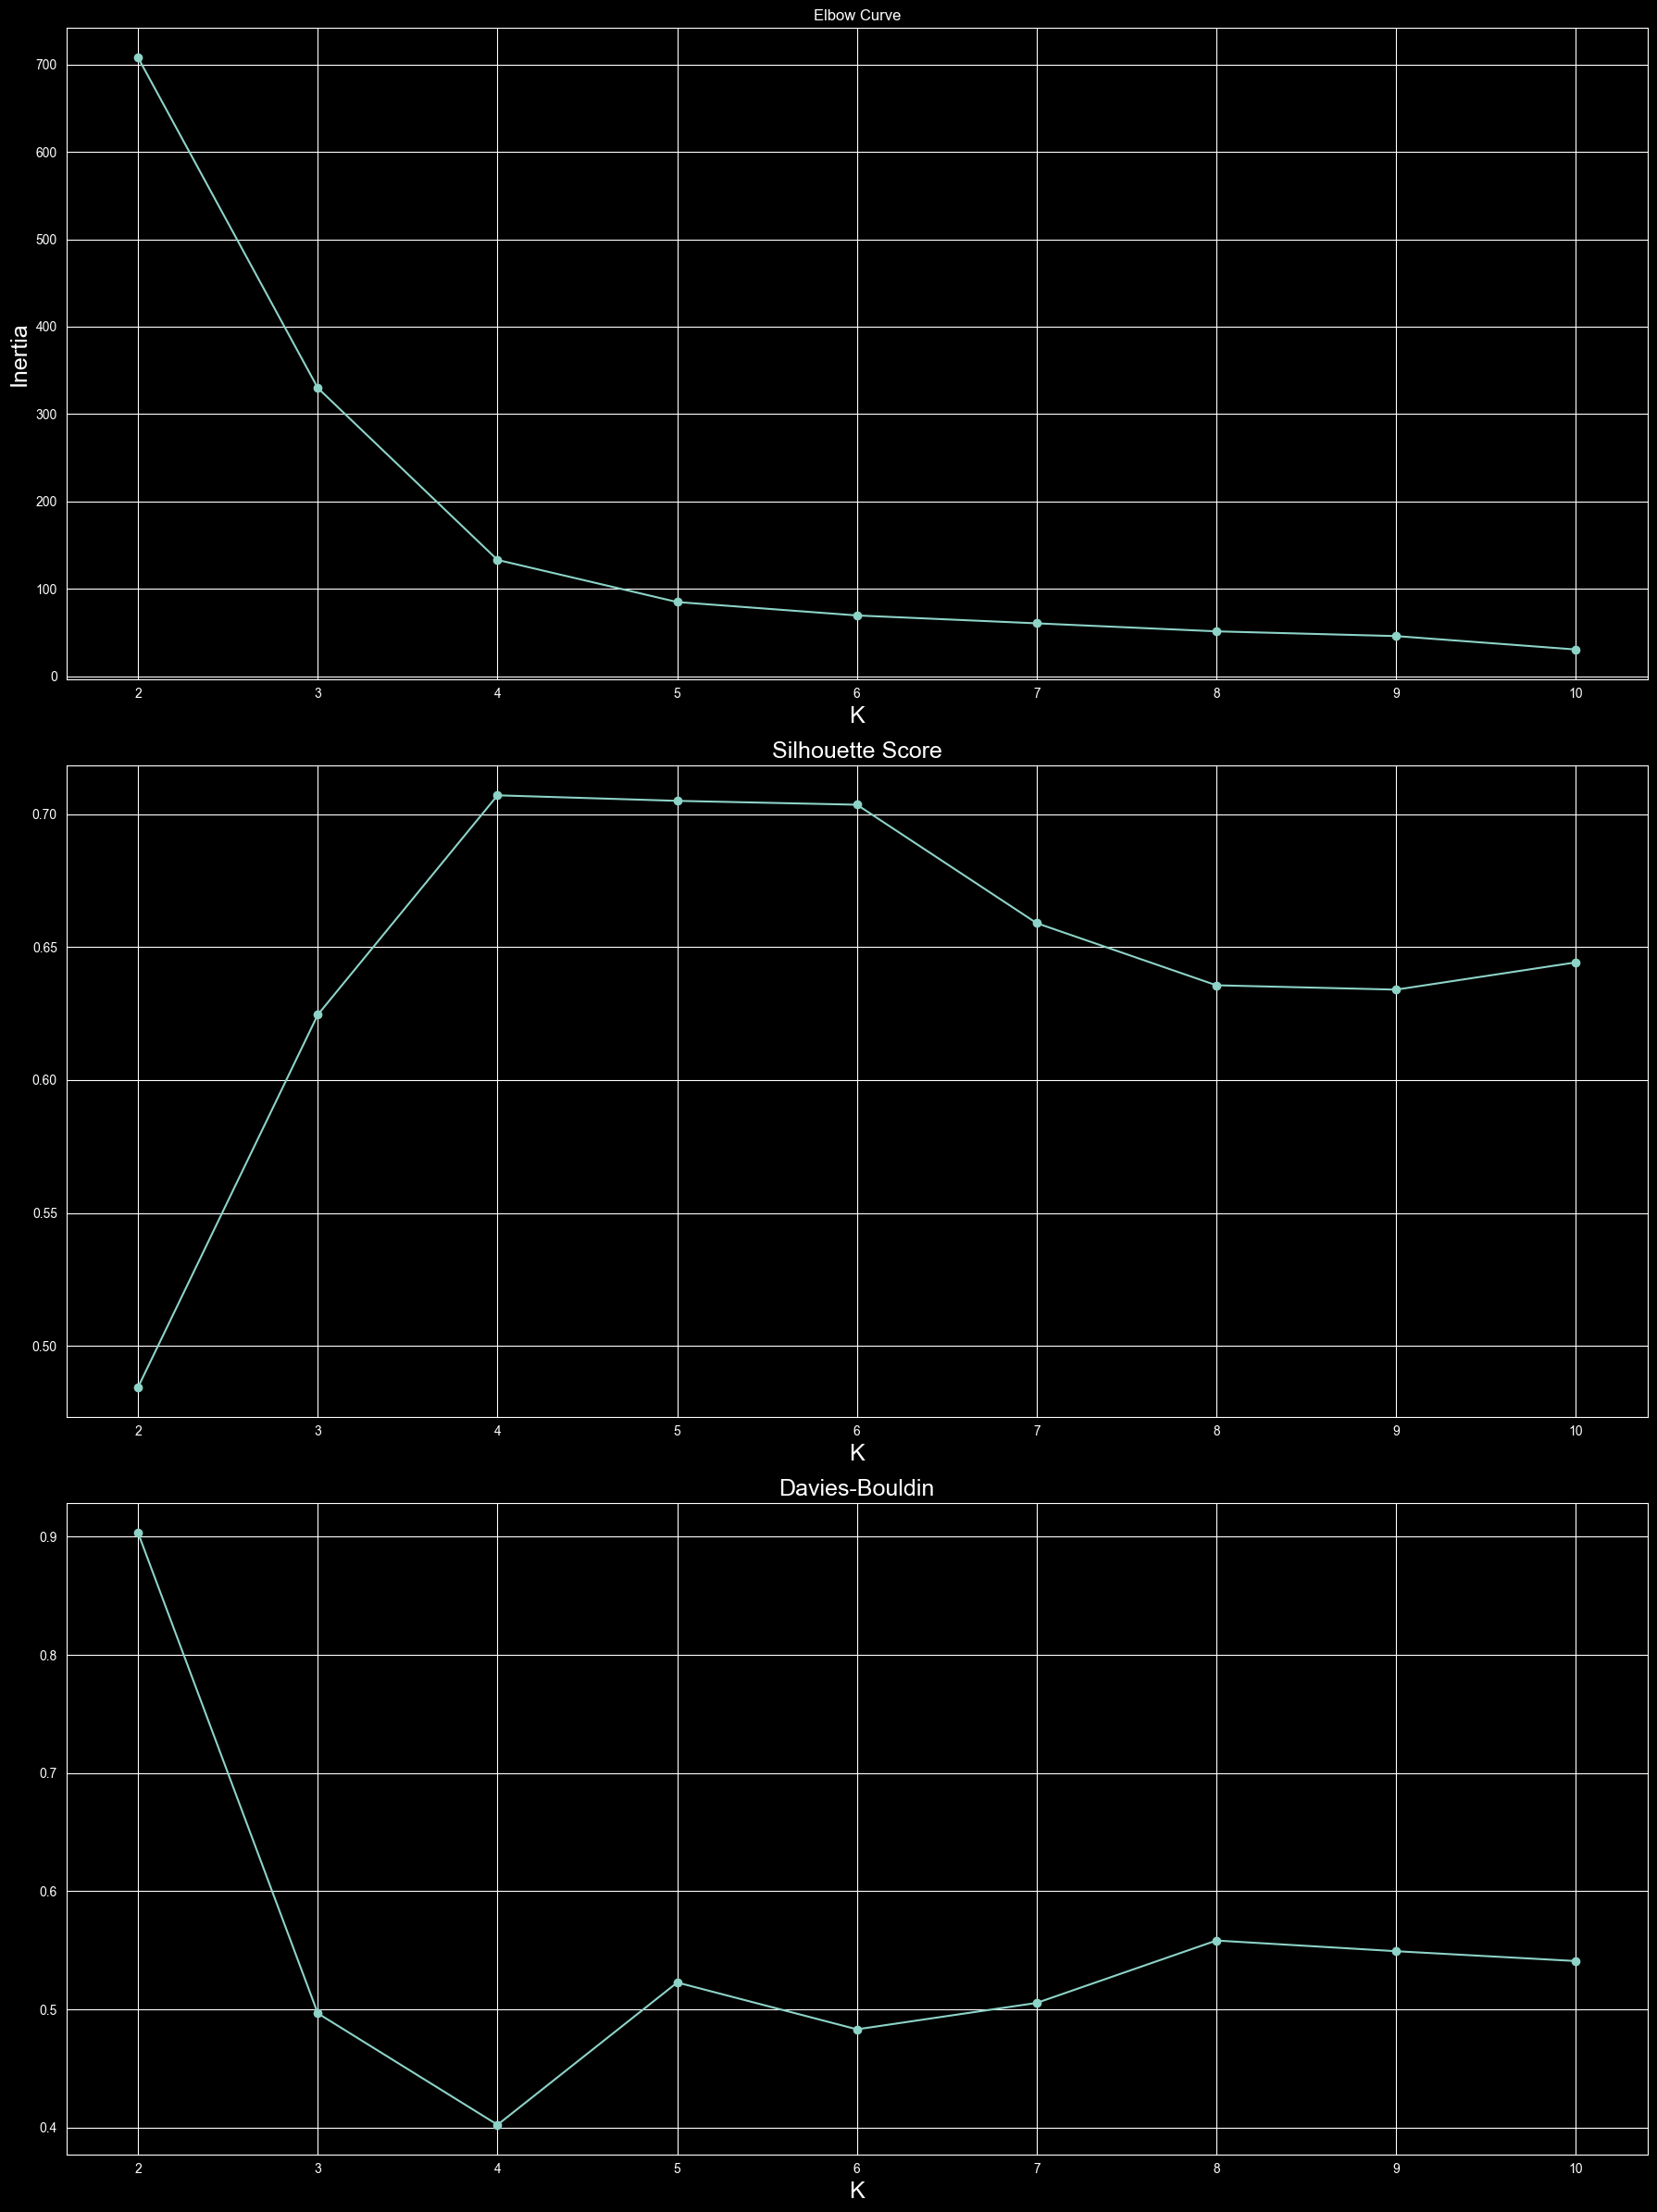

In [47]:
inertia = []
silhouette = []
davies_bouldin = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=NIA_SEED)
    labels = kmeans.fit_predict(X_pca)

    inertia.append(kmeans.inertia_)
    silhouette.append(silhouette_score(X_pca, labels))
    davies_bouldin.append(davies_bouldin_score(X_pca, labels))


figure, ax = plt.subplots(3, 1, figsize=(18, 24))

ax[0].plot(range(2, 11), inertia, marker='o')
ax[0].set_title('Elbow Curve')
ax[0].set_xlabel('K', fontsize=18)
ax[0].set_ylabel('Inertia', fontsize=18)

ax[1].plot(range(2, 11), silhouette, marker='o')
ax[1].set_title('Silhouette Score', fontsize=18)
ax[1].set_xlabel('K', fontsize=18)

ax[2].plot(range(2, 11), davies_bouldin, marker='o')
ax[2].set_title('Davies-Bouldin', fontsize=18)
ax[2].set_xlabel('K', fontsize=18)

plt.tight_layout()
plt.show()

Podemos observar que Silhouette muestra máximo en K=4 (\~0.76), y que Davies-Bouldin muestra mínimo local en K=4 (\~0.4). Además, El elbow curve se aplana a partir de K=4/K=5.

Aunque hay que recalcar, que Davies-Bouldin tiene otro minimo local en K=6 (~0.48), silhouette es similar tanto en K=4 como en K=6 y elbow también se aplana alrededor de K=6.

K=4 Silhouette: 0.7070
K=4 Davies-Bouldin: 0.4023
K=4 Silhouette: 0.7035
K=4 Davies-Bouldin: 0.4831


Text(0.5, 1.0, 'Scatter Plot - 6 Clusters')

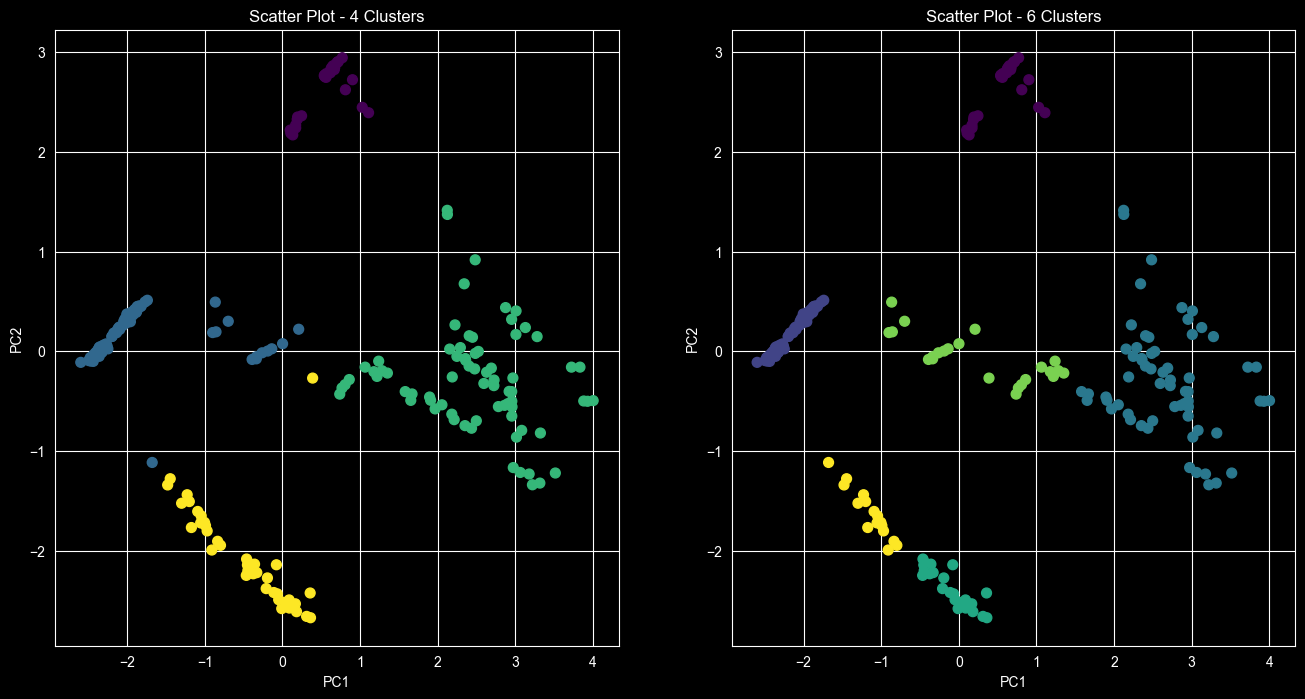

In [34]:
fig, ax = plt.subplots(1, 2, figsize=(16, 8))

kmeans = KMeans(n_clusters=4, random_state=NIA_SEED)
kmeans_labels = kmeans.fit_predict(X_pca)
print(f"K=4 Silhouette: {silhouette_score(X_pca, kmeans_labels):.4f}")
print(f"K=4 Davies-Bouldin: {davies_bouldin_score(X_pca, kmeans_labels):.4f}")

ax[0].scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_labels,
            s=50, cmap='viridis')
ax[0].set_xlabel('PC1')
ax[0].set_ylabel('PC2')
ax[0].set_title('Scatter Plot - 4 Clusters')

kmeans = KMeans(n_clusters=6, random_state=NIA_SEED)
kmeans_labels = kmeans.fit_predict(X_pca)
print(f"K=6 Silhouette: {silhouette_score(X_pca, kmeans_labels):.4f}")
print(f"K=6 Davies-Bouldin: {davies_bouldin_score(X_pca, kmeans_labels):.4f}")


ax[1].scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_labels,
            s=50, cmap='viridis');
ax[1].set_xlabel('PC1')
ax[1].set_ylabel('PC2')
ax[1].set_title('Scatter Plot - 6 Clusters')

K=4 es el mejor candidato, aunque K=6 también muestra métricas competitivas y lo evaluaremos en la comparación final. Usaremos ambos.

## Hierarchical Clustering

Empecemos por ver el dendrograma para decidir donde cortar.

In [ ]:
def plot_dendrogram(m, **kwargs):
    # create the counts of samples under each node
    counts = np.zeros(m.children_.shape[0])
    n_samples = len(m.labels_)
    for j, merge in enumerate(m.children_):
        current_count = 0
        for child_idx in merge:
            if child_idx < n_samples:
                current_count += 1  # leaf node
            else:
                current_count += counts[child_idx - n_samples]
        counts[j] = current_count

    linkage_matrix = np.column_stack(
        [m.children_, m.distances_, counts]
    ).astype(float)

    # Plot the corresponding dendrogram
    dendrogram(linkage_matrix, **kwargs)

model = AgglomerativeClustering(distance_threshold=0, n_clusters=None)
model = model.fit(X_pca)
plt.figure(figsize=(12, 6))
plt.title('Dendrogram')
plt.xlabel('Number of points in node')
plt.ylabel('Distance')
plot_dendrogram(model, truncate_mode="level", p=3)
plt.show()

Podemos observar que el salto más grande ocurre de ~21 a ~38. Ahora hay que decidir el corte más informativo para escoger K, para lograrlo, trazamos una línea horizontal y buscamos eliminar fusiones muy distintas, pero sin hacer over-segmentation. Si cortamos en 25 por ejemplo, nos quedamos con dos clusters finales (siendo las líneas que suben a ~70), y sabemos que esos grupos son muy distintos, por lo que probablemente no es un buen corte.

Un corte apropiado para este dendrograma es alrededor de 15, dando cuatro grupos que el algoritmo mantuvo separados hasta ese punto, indicando que son suficientemente distintos. Ahora bien, otro corte válido podría ser 10, dando 6 grupos. Sabemos que kmeans valora k=4 y k=6 de manera similar, así que los candidatos son (4 y 6) grupos.

In [ ]:
results = []

# HPO
for linkage in ['ward', 'complete', 'average', 'single']:
    for k in range(3, 8):
        model = AgglomerativeClustering(n_clusters=k, linkage=linkage)
        labels = model.fit_predict(X_pca)
        results.append({
            'linkage': linkage,
            'k': k,
            'silhouette': silhouette_score(X_pca, labels),
            'davies_bouldin': davies_bouldin_score(X_pca, labels)
        })

results_df = pd.DataFrame(results)

# Mejor K por cada linkage
best_per_linkage = []
for linkage in results_df['linkage'].unique():
    subset = results_df[results_df['linkage'] == linkage]
    max_sil = subset['silhouette'].max() # Get best
    candidates = subset[subset['silhouette'] >= max_sil * 0.98] # Look for all in a 2% range
    best = candidates.loc[candidates['davies_bouldin'].idxmin()] # Ties are fixed with davies
    best_per_linkage.append(best)

best_df = pd.DataFrame(best_per_linkage)
show_df(best_df.sort_values('silhouette', ascending=False).reset_index(drop=True))

# Plots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
linkages = ['ward', 'complete', 'average', 'single']

for idx, linkage in enumerate(linkages):
    subset = results_df[results_df['linkage'] == linkage]
    row, col = idx // 2, idx % 2
    ax = axes[row, col]
    ax2 = ax.twinx()

    # Plot both davies and silh
    l1 = ax.plot(subset['k'], subset['silhouette'], marker='o', color='teal', label='Silhouette')
    l2 = ax2.plot(subset['k'], subset['davies_bouldin'], marker='s', color='orange', label='Davies-Bouldin')

    ax.set_title(f'Linkage: {linkage}', fontsize=14)
    ax.set_xlabel('K')
    ax.set_ylabel('Silhouette', color='teal')
    ax2.set_ylabel('Davies-Bouldin', color='orange')

    lines = l1 + l2
    ax.legend(lines, [l.get_label() for l in lines])

plt.tight_layout()
plt.show()

Observaciones:
* `single` tiene el mejor Davies-Bouldin, pero el peor silhouette. , sabemos que tiende a hacer "chaining", es preferible usar los otros.
* `average`, `complete` y `ward` dan un silhouette similar, 0.7, pero de estos el mejor Davies-Bouldin es el de `ward`, con 6 clusters.

Nos quedamos con `linkage=ward`, no solo nos da los mejores resultados, sino que es un método que minimiza varianza dentro de un mismo cluster, perfecto para un dataset con clusters compactos como este. Usamos K=6.

In [ ]:
hierarchical = AgglomerativeClustering(n_clusters=6, linkage='ward')
hierarchical_labels = hierarchical.fit_predict(X_pca)
print(f"K=6 Silhouette: {silhouette_score(X_pca, hierarchical_labels):.4f}")
print(f"K=6 Davies-Bouldin: {davies_bouldin_score(X_pca, hierarchical_labels):.4f}")
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Scatter Plot - 6 Clusters')
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=hierarchical_labels,
            s=50, cmap='viridis');

## DBSCAN

Empecemos por encontrar un `eps` candidato, empecemos por usar el elbow method con `min_samples=5` ($2*n\_features \approx 5$).

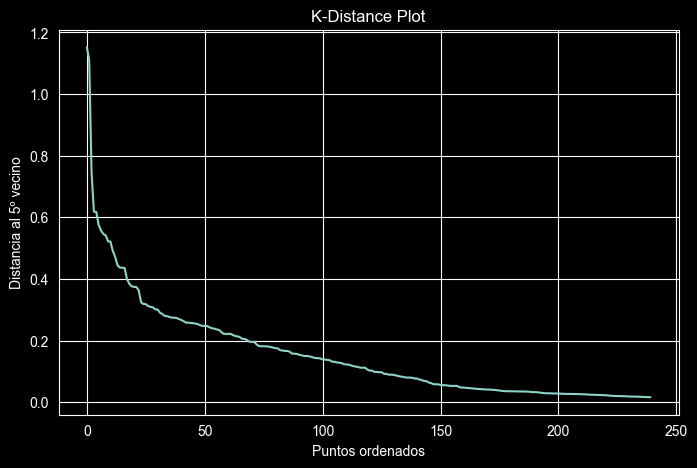

In [35]:
min_samples = 5

nbrs = NearestNeighbors(n_neighbors=min_samples).fit(X_pca)
distances, _ = nbrs.kneighbors(X_pca)

# Distancia al k-ésimo vecino (última columna)
k_distances = np.sort(distances[:, -1])[::-1]

plt.figure(figsize=(8, 5))
plt.plot(k_distances)
plt.xlabel('Puntos ordenados')
plt.ylabel(f'Distancia al {min_samples}º vecino')
plt.title('K-Distance Plot')
plt.show()

No podemos observar un candidato claro, esto probablemente se debe a que tenemos clusters compactos con densidad variada, así que no hay un solo valor claro. Lo más simple es hacer un GridSearch con valores relevantes y tomar todas las que tengan un número de clusters entre [3, 7], y un porcentaje de ruido menor a 25%.

In [44]:
eps_values = [0.05, 0.1, 0.15, 0.2, 0.3, 0.5, 0.6]
min_samples_values = [3, 4, 5, 6, 8]

results = []
for eps in eps_values:
    for ms in min_samples_values:
        labels = DBSCAN(eps=eps, min_samples=ms).fit_predict(X_pca)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = (labels == -1).sum()
        results.append({
            'eps': eps,
            'min_samples': ms,
            'n_clusters': n_clusters,
            'n_noise': n_noise,
            'noise_%': round(n_noise / len(X_pca) * 100, 1)
        })

results_df = pd.DataFrame(results)
filtered = results_df[
    (results_df['n_clusters'].between(3, 7)) &
    (results_df['noise_%'] < 25)
]
show_df(filtered)

eps,min_samples,n_clusters,n_noise,noise_%
0.30,8,6,59,24.60
0.50,3,6,2,0.80
0.50,4,6,3,1.20
0.50,5,6,3,1.20
0.50,6,5,11,4.60
0.50,8,5,12,5.00
0.60,3,4,0,0.00
0.60,4,4,2,0.80
0.60,5,4,2,0.80
0.60,6,4,2,0.80


Ahora, para estar realmente seguro, probemos estas combinaciones con DBCV.

In [45]:
dbcv_results = []
for _, row in filtered.iterrows():
    labels = DBSCAN(eps=row['eps'], min_samples=int(row['min_samples'])).fit_predict(X_pca)
    score = DBCV(X_pca, labels)
    dbcv_results.append({
        'eps': row['eps'],
        'min_samples': int(row['min_samples']),
        'n_clusters': int(row['n_clusters']),
        'n_noise': int(row['n_noise']),
        'noise_%': row['noise_%'],
        'dbcv': round(score, 4)
    })

dbcv_df = pd.DataFrame(dbcv_results)
show_df(dbcv_df.sort_values('dbcv', ascending=False).reset_index(drop=True))

eps,min_samples,n_clusters,n_noise,noise_%,dbcv
0.50,8,5,12,5.00,0.30
0.60,4,4,2,0.80,0.29
0.60,5,4,2,0.80,0.29
0.60,6,4,2,0.80,0.29
0.60,3,4,0,0.00,0.29
0.50,3,6,2,0.80,0.29
0.60,8,5,7,2.90,0.27
0.50,4,6,3,1.20,0.26
0.50,5,6,3,1.20,0.26
0.50,6,5,11,4.60,0.25


El mejor resultado es `eps=0.5` y `min_samples=8`, nos produce 5 clusters y 5% de ruido. Ahora bien, `eps=0.6` con `min_samples=3-6`, produce 4 clusters con 0-1% de ruido y un DBCV casi idéntico (0.3 vs. 0.29), esta opción es más estable. Sin embargo, tomaremos la combinación ganadora.

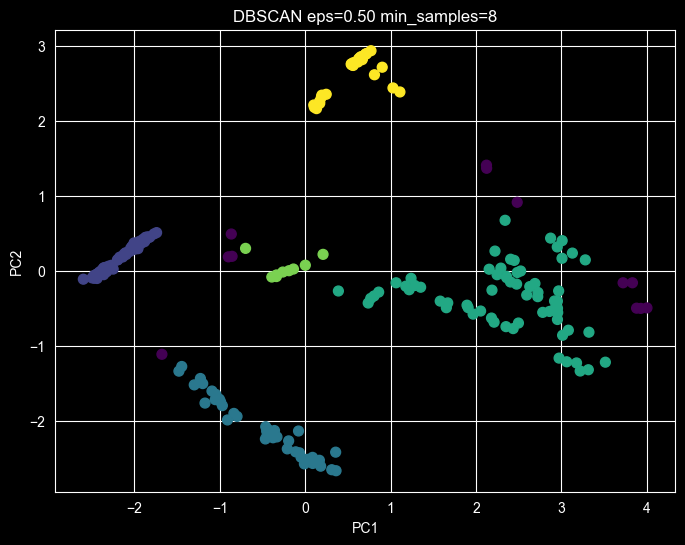

In [46]:
dbscan = DBSCAN(eps=0.50, min_samples=8)
dbscan_labels = dbscan.fit_predict(X_pca)

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=dbscan_labels, s=50, cmap='viridis')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('DBSCAN eps=0.50 min_samples=8')
plt.show()

Podemos observar que DBSCAN en esta configuración crea 5 clusters y elimina mucho ruido. Podemos ver en particular, un cluster en el centro, que aunque puede pertenecer al de la derecha, prefiere separarlo. Esto tiene sentido, ese cluster (en verde) es mucho más denso que el cyan de la derecha, que está más disperso.

## Comparación y Conclusiones

Comparar los algoritmos entre sí es complejo. No podemos hacer una comparación lineal porque tienen diferentes clusters y DBSCAN usa otras métricas. Asi que comparemos:
* kmeans con `k=4`.
* DBSCAN con `eps=0.5`, `min_samples=8`, dando 5 clusters.
* kmeans con `k=6` ya que es similar a 4 en nuestro análisis.
* hierarchical con `k=6` y `linkage=ward`.

También aproximemos con silhouette y Davies-Bouldin para todos (Aunque en DBSCAN no sea la metrica óptima).

In [ ]:
fig, ax = plt.subplots(2, 2, figsize=(24, 16))

kmeans = KMeans(n_clusters=4, random_state=NIA_SEED)
kmeans_labels = kmeans.fit_predict(X_pca)
ax[0, 0].scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_labels, s=50, cmap='viridis')
ax[0, 0].set_title('KMeans n_clusters=4')
ax[0, 0].set_xlabel('PC1')
ax[0, 0].set_ylabel('PC2')

dbscan = DBSCAN(eps=0.50, min_samples=8)
dbscan_labels = dbscan.fit_predict(X_pca)
ax[0, 1].scatter(X_pca[:, 0], X_pca[:, 1], c=dbscan_labels, s=50, cmap='viridis')
ax[0, 1].set_title('DBSCAN eps=0.50 min_samples=8')
ax[0, 1].set_xlabel('PC1')
ax[0, 1].set_ylabel('PC2')

kmeans_2 = KMeans(n_clusters=6, random_state=NIA_SEED)
kmeans_labels_2 = kmeans_2.fit_predict(X_pca)
ax[1, 0].scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_labels_2, s=50, cmap='viridis')
ax[1, 0].set_title('KMeans n_clusters=6')
ax[1, 0].set_xlabel('PC1')
ax[1, 0].set_ylabel('PC2')

hierarchical = AgglomerativeClustering(n_clusters=6, linkage='ward')
hierarchical_labels = hierarchical.fit_predict(X_pca)
ax[1, 1].scatter(X_pca[:, 0], X_pca[:, 1], c=hierarchical_labels, s=50, cmap='viridis')
ax[1, 1].set_title('Hierarchical n_clusters=6 linkage=ward')
ax[1, 1].set_xlabel('PC1')
ax[1, 1].set_ylabel('PC2')


mask = dbscan_labels != -1

comparison = pd.DataFrame([
    {
        'Algorithm': 'K-Means (K=4)',
        'Silhouette': silhouette_score(X_pca, kmeans_labels),
        'Davies-Bouldin': davies_bouldin_score(X_pca, kmeans_labels),
        'N Clusters': 4,
    },
        {
        'Algorithm': 'DBSCAN (eps=0.50, ms=8)',
        'Silhouette': silhouette_score(X_pca[mask], dbscan_labels[mask]),
        'Davies-Bouldin': davies_bouldin_score(X_pca[mask], dbscan_labels[mask]),
        'N Clusters': 5,
    },
    {
        'Algorithm': 'K-Means (K=6)',
        'Silhouette': silhouette_score(X_pca, kmeans_labels_2),
        'Davies-Bouldin': davies_bouldin_score(X_pca, kmeans_labels_2),
        'N Clusters': 6,
    },
    {
        'Algorithm': 'Hierarchical (ward K=6)',
        'Silhouette': silhouette_score(X_pca, hierarchical_labels),
        'Davies-Bouldin': davies_bouldin_score(X_pca, hierarchical_labels),
        'N Clusters': 6,
    },

])

show_df(comparison)

Observaciones:
* K-Means con `k=4` tiene dos puntos (amarillo y azul), que están en clusters de otros grupos. Lo interesante es que DBSCAN que produce 5 clusters los asigna o a otro grupo o como ruido. Esto es importante, kmeans en esta configuración tiene un conflicto con DBSCAN.
* Todos los algoritmos que producen más de 4 clusters crean un grupo en el centro. K-Means con `k=4` une esa sección céntrica y la asigna al grupo más cercano porque no tiene otra opción, cuando el resto está de acuerdo que en el centro si hay un cluster válido.
* Lo más util es que tanto K-Means con `k=6` como hierarchical con `k=6, ward` coinciden en la misma distribución, son idénticos. Dos algoritmos diferentes llegaron a lo mismo. Esto es un indicativo de que refleja estructura real en los datos, no un artefacto de un algoritmo específico.
* El Davies-Bouldin score de DBSCAN, aunque el más bajo, está distorsionado, ya que eliminamos el ruido para calcularlo. Si incluimos los 12 puntos de ruido, el score empeoraría.

### Pipeline Recomendado

Con esto en mente, considero que kmeans con `k=6` es el mejor algoritmo, estas son las razones:
1. Consistencia entre algoritmos: Coincide con Hierarchical con `k=6`.
2. Las métricas de DBSCAN están infladas: Davies-Bouldin de 0.36 se calcula excluyendo el ruido. La comparación no es completamente justa.
3. K-Means es más apropiado para este dataset: Los clusters en el PCA scatter son compactos y aproximadamente convexos. DBSCAN es mejor con clusters con forma arbitraria.

Aunque definimos kmeans con `k=4` en su sección, habíamos determinado que `k=6` era un buen candidato, muy similar a 4. Por lo que no solo usamos un candidato que previamente fue considerado como fuerte, sino que mostramos en la comparación final que es el que más sentido tiene.

# Grupos Finales Vs. Astronomía

Usando el algoritmo recomendado, asignemos un tipo astronómico a cada cluster.

In [ ]:
df_model['cluster'] = kmeans_labels_2  # K-Means K=6
df['cluster'] = df_model['cluster'].values

summary = df.groupby('cluster')[['Temperature', 'L', 'R', 'A_M']].mean().sort_values(by='Temperature', ascending=True)
show_df(summary, precision=4)

Los 6 clusters obtenidos por K-Means `k=6` corresponden aproximadamente con los 6 tipos astronómicos de la tabla de referencia. Ordenando por temperatura:

* **Cluster T=3140** (L=0.003, R=0.23, A_M=+15) → **Enana roja**: fría, pequeña y tenue. Buena correspondencia en L, R y A_M.
* **Cluster T=3689** (L=234088, R=1020, A_M=-9) → **Hipergigante**: la temperatura es menor que la referencia (~11000K), pero L, R y A_M coinciden. Puede tratarse de una hipergigante roja fría, tipo no distinguido explícitamente en la tabla.
* **Cluster T=8217** (L=217, R=2.7, A_M=+2.1) → **Secuencia principal**: valores intermedios en todas las variables, consistente con el tipo.
* **Cluster T=9569** (L=0.0003, R=0.01, A_M=+13.7) → **Enana blanca**: R y A_M coinciden perfectamente con la referencia.
* **Cluster T=16839** (L=0.004, R=0.01, A_M=+11.8) → **Enana marrón o enana blanca caliente**: ambigüedad con el cluster anterior, ambos tienen R y A_M similares pero distinta temperatura.
* **Cluster T=22165** (L=281923, R=351, A_M=-6.3) → **Supergigante**: A_M coincide perfectamente (-6.4 en la tabla), L similar.

La correspondencia es sólida en L, R y A_M. La temperatura introduce ambigüedad en algunos casos, lo que es consistente con lo observado en el EDA, Temperature y R tienen correlación ~0, por lo que temperatura sola no es suficiente para distinguir todos los tipos. Las ambigüedades restantes reflejan limitaciones del feature space, no del algoritmo.